# Imports

In [2]:
import numpy as np
import networkx as nx
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from scipy import linalg as la
from collections import Counter
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import time as tm
import pandas as pd
from scipy.optimize import minimize
import pickle



# import all from helper-functions-SR.py
from helper_functions_SR import *


## Function to do 2-step task (random walk probabilities)

In [3]:
import numpy as np

n_trials = 5000         # total number of trials
n_probs = 4             # number of independent probability streams
noise_std = 0.025       # SD of Gaussian diffusion
lower_bound = 0.25
upper_bound = 0.75

# Initialize probabilities randomly within the bounds
probabilities = np.random.uniform(lower_bound, upper_bound, size=(n_trials, n_probs))
probabilities[0] = [0.75,0.5,0.4,0.25]

# Generate random walks
for i in range(1, n_trials):
    # Add Gaussian noise to previous step
    probabilities[i] = probabilities[i - 1] + np.random.normal(0, noise_std, size=n_probs)
    
    # Reflecting boundaries
    below = probabilities[i] < lower_bound
    above = probabilities[i] > upper_bound
    
    probabilities[i][below] = 2 * lower_bound - probabilities[i][below]
    probabilities[i][above] = 2 * upper_bound - probabilities[i][above]

# Optional: split into named vectors for clarity
prob1, prob2, prob3, prob4 = probabilities.T

print(prob1)
print(prob2)
print(prob3)
print(prob4)

[0.75       0.7361853  0.70683414 ... 0.56779424 0.60891285 0.599281  ]
[0.5        0.52259664 0.50896617 ... 0.64938623 0.65011128 0.61816473]
[0.4        0.4237912  0.4329885  ... 0.74330855 0.72326151 0.74523381]
[0.25       0.26622893 0.32086705 ... 0.42452773 0.44722652 0.44303058]


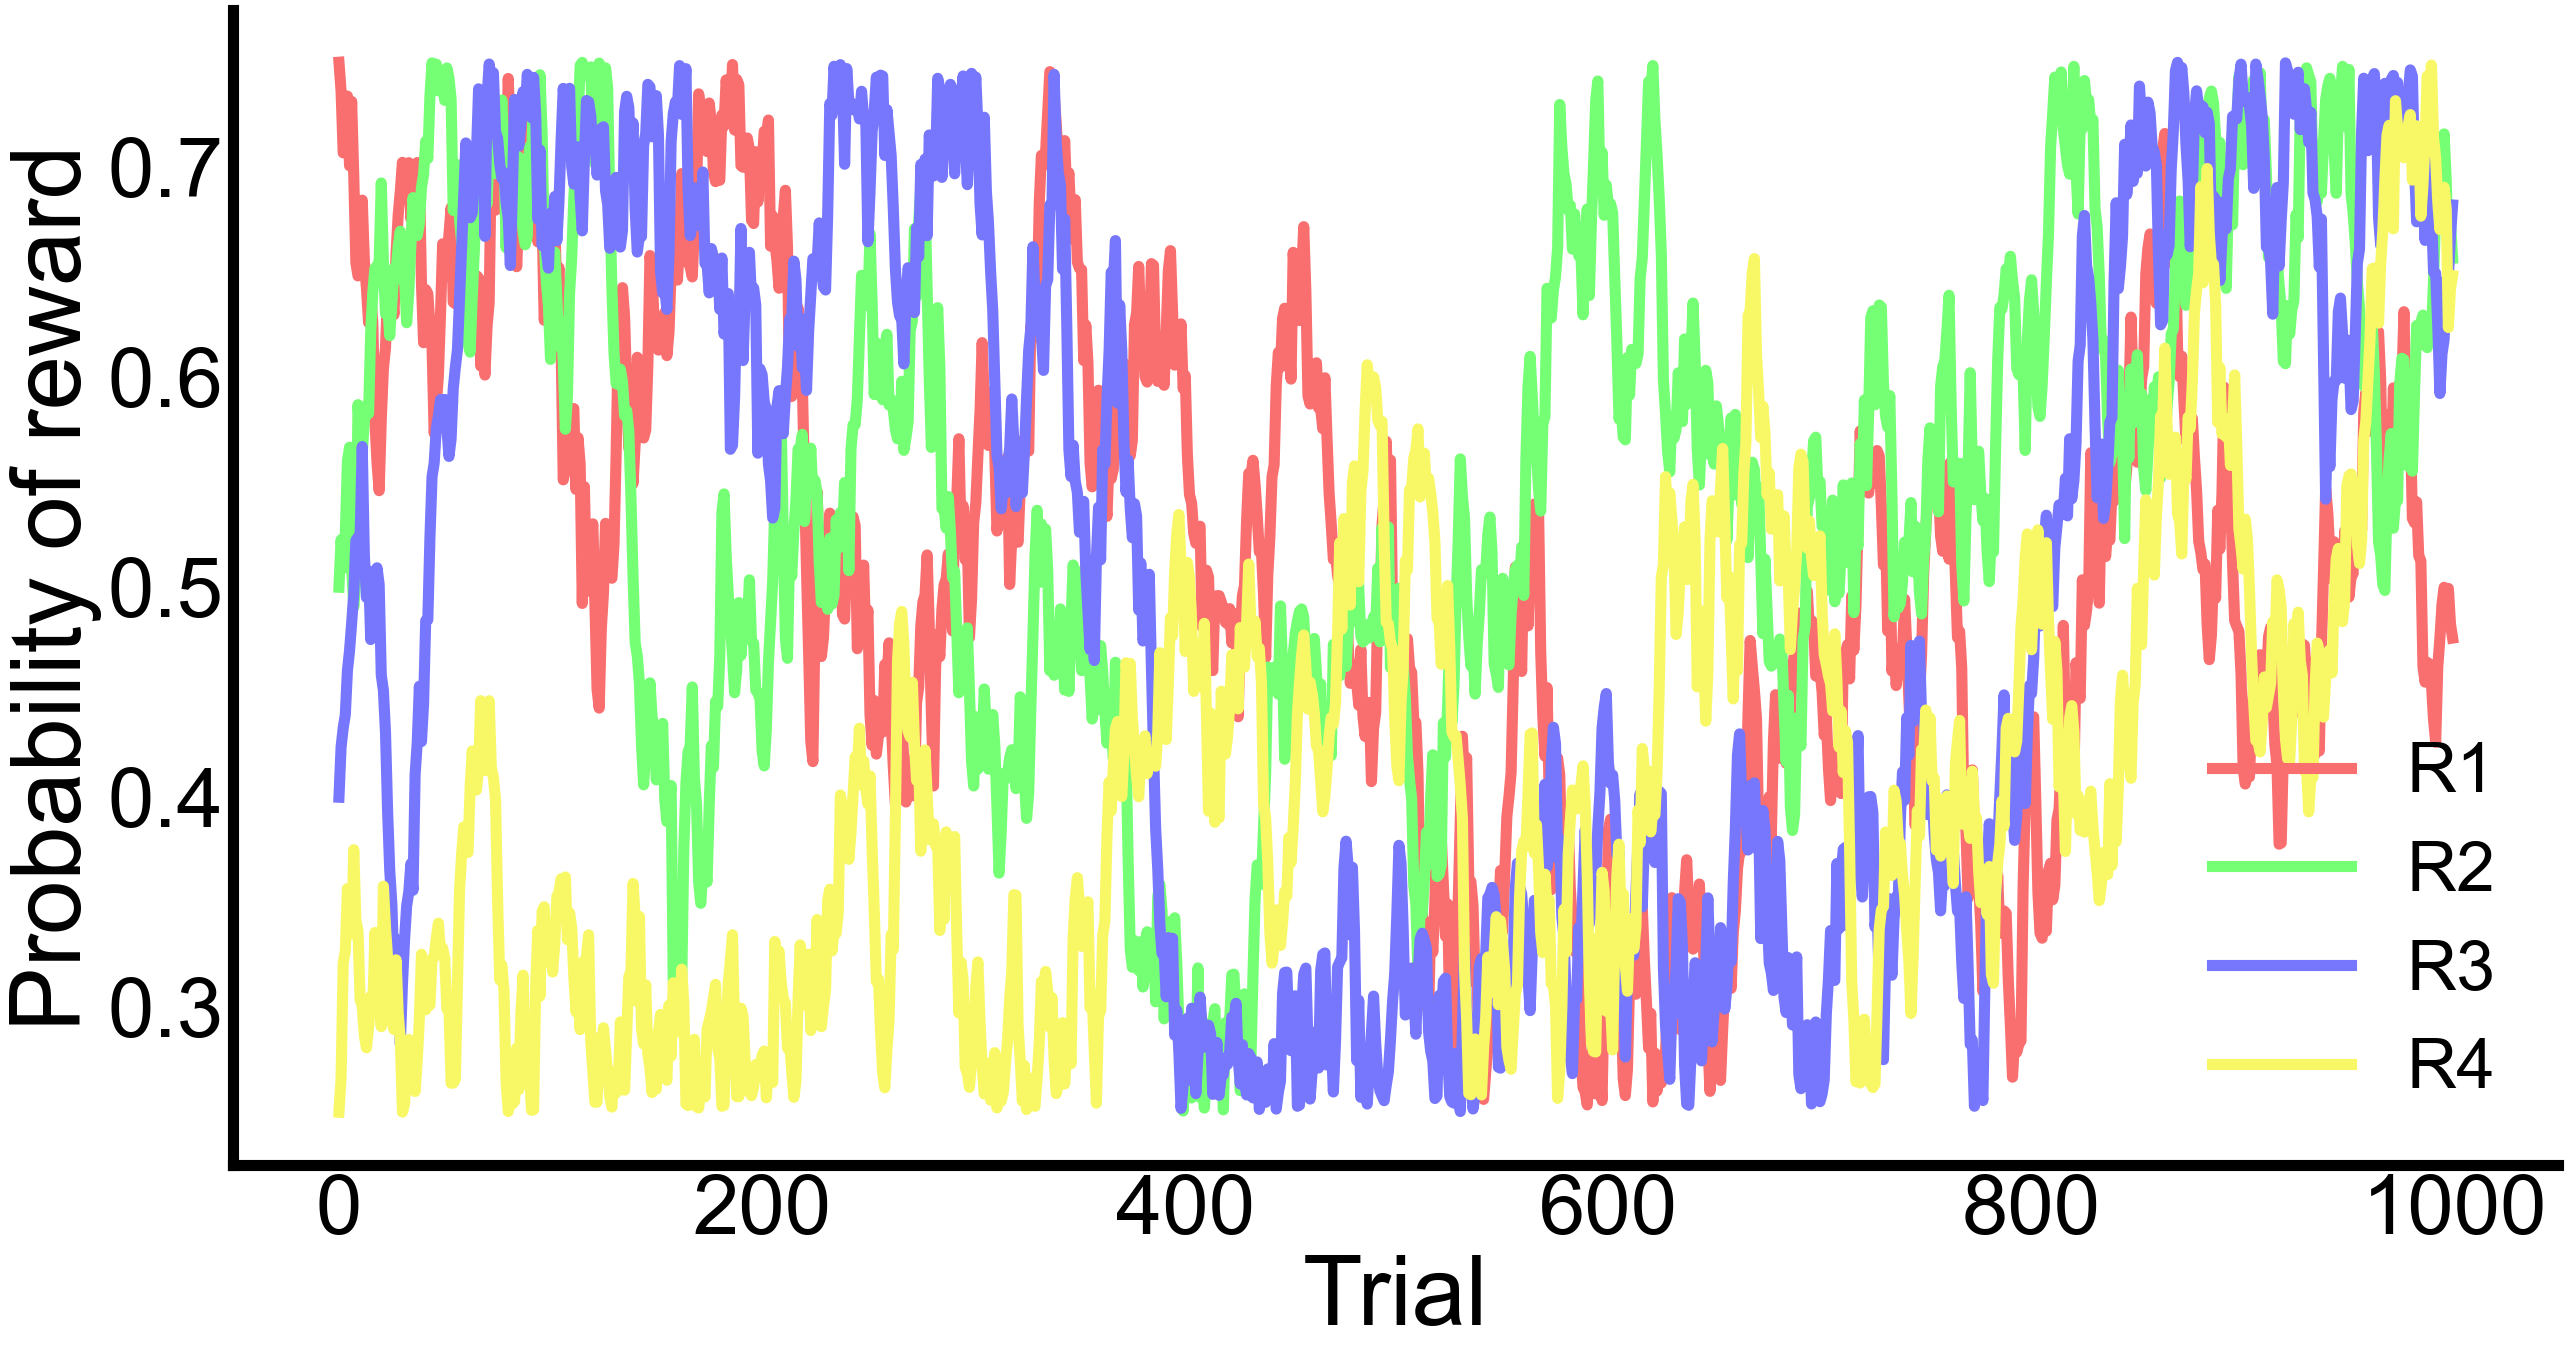

In [5]:
plt.figure(figsize=(30, 15))

# font type arial
plt.rcParams["font.family"] = "Arial"
plt.plot(prob1[:1000],lw =8 , color = "#F96E6E",label = 'R1')
plt.plot(prob2[:1000], lw =8 , color = "#75FF75",label = 'R2')
plt.plot(prob3[:1000],lw =8 , color = "#7777FD",label = 'R3')
plt.plot(prob4[:1000], lw =8 , color = "#F8F867",label = 'R4')

plt.ylabel('Probability of reward',fontsize=70)
plt.xlabel('Trial',fontsize=70)
# ticks size 
plt.xticks(fontsize=60)
plt.yticks(fontsize=60)
# axis line thickness
plt.gca().spines['left'].set_linewidth(8)
plt.gca().spines['bottom'].set_linewidth(8)
sns.despine()
# savefig

plt.legend(fontsize=50, frameon=False, loc = "lower right")
# plt.savefig('FiguresGraph_randomWalk_Human2Step/SGM2025_Human2Step_simulations_model2_newStay.svg', dpi=300, format='svg', bbox_inches='tight')

In [ ]:
# use our model and generate the 4-bar graph for human 2step task

def doHuman2step(learning_rate_transformed, discount_transformed,  threshold_transformed, temperature_transformed, learning_rate_rew_nostim_transformed, reward_learning_rate_transformed, stay_bias_transformed,n_episodes = 200):
    learning_rate = 1/(1 + np.exp(-learning_rate_transformed))
    discount = 1/(1 + np.exp(-discount_transformed))
    threshold = 1/(1 + np.exp(-threshold_transformed))
    temperature = np.exp(temperature_transformed)
    learning_rate_rew_nostim = 1/(1 + np.exp(-learning_rate_rew_nostim_transformed))
    reward_learning_rate = 1/(1 + np.exp(-reward_learning_rate_transformed))
    
    # stay_bias = 1/(1 + np.exp(-stay_bias_transformed))
    stay_bias = np.tanh(stay_bias_transformed)

    states = ['up','down','left','right']
    given_rewards = [0,0,1,0]
    actual_transition_matrix = np.zeros((len(states),len(states)))
    actual_transition_matrix[0,2] = 0.7
    actual_transition_matrix[0,3] = 0.3
    actual_transition_matrix[1,2] = 0.3
    actual_transition_matrix[1,3] = 0.7
    # left_walk = walk1
    # right_walk = walk2
    successor_representation = np.zeros((len(states),len(states)))
    thresholded_successor = np.zeros((len(states),len(states)))
    thresholded_successor_list = []
    values_list = []
    rewards_list = []
    graph_list = []
    choices = []
    preferences = []
    rewards = np.zeros(len(states))
    terminal_states = ['left','right']
    graph = np.zeros((len(states),len(states)))
    results = pd.DataFrame(columns=['choices', 'choice_probs', 'second_steps', 'outcomes', 'transitions','free_choice', 'stage', 'mov_average', 'stim', 'stim_type', 'block'])
    left_prob_list = []
    right_prob_list = []



    # =--------- RANDOM WALK FOR REWARD PROBABILITIES

    block_mean = 40      # average block length
    jitter = 10          # random variation in block length
    transition_len = 5   # number of trials for smooth transition
    noise_std = 0.02     # standard deviation of added noise

    
    current_p = 0.2



    n_trials = n_episodes         # total number of trials
    n_probs = 4             # number of independent probability streams

    noise_std = 0.025       # SD of Gaussian diffusion
    lower_bound = 0.25
    upper_bound = 0.75


    # Initialize probabilities randomly within the bounds
    probabilities = np.random.uniform(lower_bound, upper_bound, size=(n_trials, n_probs))
    probabilities[0] = [0.75,0.5,0.4,0.25]
    # Generate random walks
    for i in range(1, n_trials):
        # Add Gaussian noise to previous step
        probabilities[i] = probabilities[i - 1] + np.random.normal(0, noise_std, size=n_probs)
        
        # Reflecting boundaries
        below = probabilities[i] < lower_bound
        above = probabilities[i] > upper_bound
        
        probabilities[i][below] = 2 * lower_bound - probabilities[i][below]
        probabilities[i][above] = 2 * upper_bound - probabilities[i][above]

    # Optional: split into named vectors for clarity
    prob1, prob2, prob3, prob4 = probabilities.T


    lapse_rate = 0.00000000000000000001
    prev_choice = 0

    for i in range(n_episodes):

        # get the current state based on the graph
        values = get_values_from_graph_2(rewards,graph)
        values_list.append(values.copy())
        value_up = values[0]
        value_down = values[1]
        vlist = [value_up,value_down]




        # Stay bias incorporated into value difference
        prev_choice_idx = max(0, i - 1)
        if i > 0:
            prev_choice = choices[i - 1]
        else:
            prev_choice = 0  # arbitrary for first trial
            
        has_prev = 1.0 * (i > 0)
        stay_bias_term = has_prev * stay_bias * (1.0 - 2.0 * (1-prev_choice))

        value_diff = value_down - value_up + stay_bias_term
        preference_up = 1.0 / (1.0 + np.exp(value_diff / temperature))
        preference_up = (1 - lapse_rate) * preference_up + lapse_rate * 0.5

        preference_down = 1 - preference_up
        # make a choice
        choice = np.random.choice([0,1], p=[preference_up, preference_down])
        choices.append(choice)
        current_state = states[choice]
        # get the index of the current state
        current_state_index = states.index(current_state)
        # get the next state
        next_state = np.random.choice(['left','right'], p=actual_transition_matrix[current_state_index,2:])
        # get the index of the next state
        next_state_index = states.index(next_state)
        if next_state == 'left':
            second_step = 0
        else:
            second_step = 1

        # get the transition type
        if current_state_index == 0 and next_state_index == 2:
            transition = 1
        elif current_state_index == 1 and next_state_index == 3:
            transition = 1
        elif current_state_index == 0 and next_state_index == 3:
            transition = 0
        elif current_state_index == 1 and next_state_index == 2:
            transition = 0


        # get reward depending on the terminal state    
        if next_state == 'left':
            # get the optimal choice given prob1 and prob2
            if prob1[i] > prob2[i]:
                left_reward_prob = prob1[i]
            elif prob2[i] >= prob1[i]:
                left_reward_prob = prob2[i]
            # else:
            #     left_reward_prob = 0.5
            reward = np.random.choice([0,1], p=[1-left_reward_prob,left_reward_prob])
        else:
            # get the optimal choice given prob3 and prob4
            if prob3[i] > prob4[i]:
                right_reward_prob = prob3[i]
            elif prob4[i] >= prob3[i]:
                right_reward_prob = prob4[i]
            # else:
            #     right_reward_prob = 0.5
            reward = np.random.choice([0,1], p=[1-right_reward_prob,right_reward_prob])
        

        # get the TD error
        if reward == 1:
            outcome = 1
        else:
            outcome = 0

        
        rewards[next_state_index] = rewards[next_state_index]*(1 - reward_learning_rate) + reward_learning_rate*reward

        # get the value of the next state
        values = get_values_from_graph_2(rewards,thresholded_successor)
        if outcome ==  1:
            lr = learning_rate_rew_nostim
            # print('reward')
            # print(outcome)
        else:
            lr = learning_rate
            # print('noReward')

        td_error = np.eye(len(states))[next_state_index,:] - successor_representation[current_state_index,:] + discount * successor_representation[next_state_index,:]
        # update the successor representation
        successor_representation[current_state_index,:] = successor_representation[current_state_index,:] + lr * td_error
        # update the thresholded successor representation

        # print("SR:", np.max(successor_representation))

        thresholded_successor = successor_representation.copy()
        thresholded_successor[thresholded_successor < threshold] = 0
        thresholded_successor[thresholded_successor >= threshold] = 1
        #for state in other_states:
            #other_state_number = states.index(state)
            #rewards[other_state_number] = rewards[other_state_number]*(0.99)
        rewards_list.append(rewards.copy())
        graph_list.append(thresholded_successor.copy())
        # update the graph
        graph = thresholded_successor.copy()

        # append the trial result
        results = pd.concat([results, pd.DataFrame({'choices': choice,
                                                    'choice_probs': preference_down,
                                                    'second_steps': second_step,
                                                    'outcomes': outcome,
                                                    'transitions': transition,
                                                    'free_choice': 0,
                                                    'stage': 4.7,
                                                    'mov_average': 0,
                                                    'stim': 0,
                                                    'stim_type': 'outcome_cue',
                                                    'block': 0}, index=[0])], axis=0, ignore_index=True)
    return results, graph_list, values_list, rewards_list, left_prob_list, right_prob_list



# Running a parameter sweep for the 2-step task

In [ ]:
import itertools
import pandas as pd

In [ ]:

learning_rates = inv_logit(np.linspace(0.01, 0.9, 4))        # multiple learning rates
discounts = inv_logit(np.linspace(0.001, 0.9, 4))
thresholds = inv_logit(np.linspace(0.01, 0.9, 4))
temperatures = np.log(np.linspace(0.5, 1.5, 2))
learning_rate_rew_nostims = inv_logit(np.linspace(0.01, 0.9, 4))
reward_learning_rates = inv_logit(np.linspace(0.01, 0.9, 4))
stay_biases = inv_logit(np.linspace(0.01, 0.9, 4))

n_episodes = 2000

# Create list of all combinations of the parameters
param_combinations = list(itertools.product(
    learning_rates, discounts, thresholds, temperatures,
    learning_rate_rew_nostims, reward_learning_rates, stay_biases
))

# Create a dataframe to store results
results_df = pd.DataFrame(columns=[
    'learning_rate', 'discount', 'threshold', 'temperature',
    'learning_rate_rew_nostim', 'reward_learning_rate',
    'stay_bias', 'n_episodes','loglikelihood'
])



In [ ]:
# Probabilities observed in Daw et al. 2011 human two-step task

target_vector = np.array([0.88, 0.75, 0.63, 0.70])
# generate barplot for target_vector
plt.figure(figsize=(5, 5))
plt.bar(['R1', 'R2', 'R3', 'R4'], target_vector)
plt.ylim(0, 1)
plt.ylabel('Target Reward Probability', fontsize=20)
plt.ylim(0.5, 1)
plt.show()

In [ ]:
from joblib import Parallel, delayed

# Define worker function
def process_params(i, params, target_vector, n_episodes):
    """Process a single parameter combination"""
    learning_rate, discount, threshold, temperature, learning_rate_rew_nostim, reward_learning_rate, stay_bias = params

    # Run the model
    results, graph_list, values_list, rewards_list, left_prob_list, right_prob_list = doHuman2step(
        learning_rate, discount, threshold, temperature,
        learning_rate_rew_nostim, reward_learning_rate, stay_bias, n_episodes
    )

    # Store parameter info
    params_df = pd.DataFrame({
        'parameter': [
            'learning_rate', 'discount', 'threshold', 'temperature',
            'learning_rate_rew_nostim', 'reward_learning_rate',
            'stay_bias', 'n_episodes'
        ],
        'value': [
            logit(learning_rate),
            logit(discount),
            logit(threshold),
            np.exp(temperature),
            logit(learning_rate_rew_nostim),
            logit(reward_learning_rate),
            logit(stay_bias),
            n_episodes
        ]
    })

    # Generate and store summary
    summary = plot_from_results_2(results, params_df, filename=f'', plotOn=0)

    # Estimate log likelihood
    pred = summary.Stay_Probability.values
    sigma = np.std(target_vector - pred)
    loglik = -0.5 * np.sum(((target_vector - pred) / sigma)**2) \
            - len(target_vector) * np.log(sigma * np.sqrt(2*np.pi))
    
    return [
        logit(learning_rate),
        logit(discount),
        logit(threshold),
        np.exp(temperature),
        logit(learning_rate_rew_nostim),
        logit(reward_learning_rate),
        logit(stay_bias),
        n_episodes, loglik
    ]

# Run in parallel
print("Running parameter combinations in parallel...")
results_list = Parallel(n_jobs=-1, verbose=10)(
    delayed(process_params)(i, params, target_vector, n_episodes)
    for i, params in enumerate(param_combinations)
)

# Fill results dataframe
for i, row_data in enumerate(results_list):
    results_df.loc[i] = row_data

print("All parameter combinations completed!")

In [ ]:
results_df00 = results_df.copy()

In [ ]:
results_df00.to_csv('parameter_iterations_human2step_FEB8_correct.csv')

In [ ]:
# load csv
# results_df00 = pd.read_csv('parameter_iterations_human2step_FEB3.csv')

In [ ]:
# identify parameters for higher loglikelihood from dataframe
params_max = results_df00.loc[results_df00['loglikelihood'] == np.max(results_df00.loglikelihood)]
params_maxs = results_df00.loc[results_df00['loglikelihood'] >4]

/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_50976/2347035685.py:323: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame({'choices': choice,
/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/Figures Editable/code figures/adtihya_code/helper_functions_SR.py:630: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Condition'] = df_clean.apply(label_condit

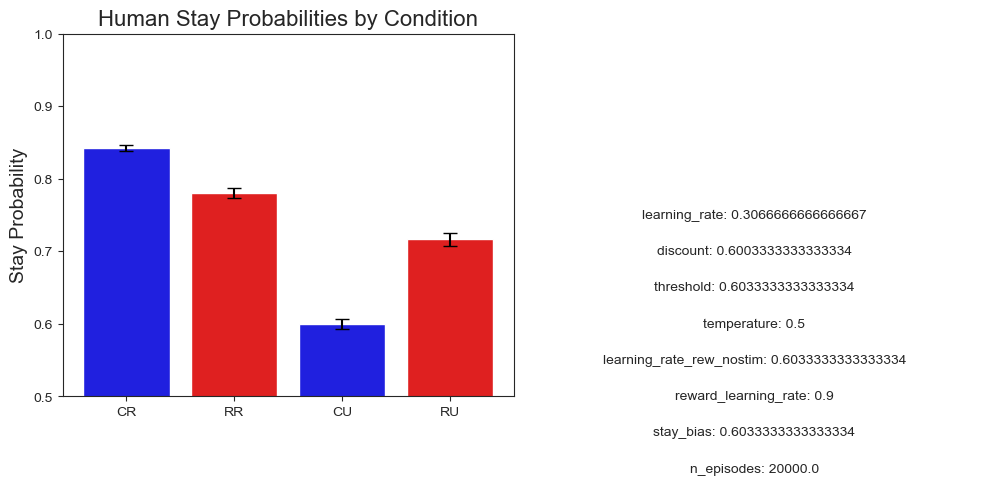

Finished 1/1 combinations


In [ ]:
fourBarStore = []

''' Below are lists of parameters. This is currently set with the best parameters, but it can be modified as per needed'''
learning_rates = [ inv_logit(params_max.learning_rate.values[0])]
discounts = [inv_logit(params_max.discount.values[0])]
thresholds = [inv_logit(params_max.threshold.values[0])]
# thresholds = inv_logit(thresholds)
temperatures = [np.log(params_max.temperature.values[0])]
learning_rate_rew_nostims = [inv_logit(params_max.learning_rate_rew_nostim.values[0])]
reward_learning_rates = [inv_logit(params_max.reward_learning_rate.values[0])]
stay_biases = [inv_logit(params_max.stay_bias.values[0])]
n_episodes = 20000



params = [learning_rates, discounts, thresholds, temperatures, learning_rate_rew_nostims, reward_learning_rates, stay_biases]
# create a list of all combinations of the parameters
import itertools
import pandas as pd

# create a list of all combinations of the parameters
param_combinations = list(itertools.product(learning_rates, discounts, thresholds, temperatures, learning_rate_rew_nostims, reward_learning_rates, stay_biases))
# above line does not work, 'numpy.float64' object is not iterable
# create a list of all combinations of the parameters

# create a dataframe to store the results
results_df = pd.DataFrame(columns=['learning_rate', 'discount', 'threshold', 'temperature', 'learning_rate_rew_nostim', 'reward_learning_rate', 'stay_bias', 'n_episodes', 'results', 'summary','params'])
# loop over all combinations of the parameters
# for i, params in enumerate(param_combinations):
for i in range(1):


    learning_rate, discount, threshold, temperature, learning_rate_rew_nostim, reward_learning_rate, stay_bias = params
    learning_rate = learning_rate[0]
    discount = discount[0]
    threshold = threshold[0]
    temperature = temperature[0]
    learning_rate_rew_nostim = learning_rate_rew_nostim[0]
    reward_learning_rate = reward_learning_rate[0]
    stay_bias = stay_bias[0]

    # run the model
    results, graph_list, values_list, rewards_list, left_prob_list, right_prob_list = doHuman2step(learning_rate, discount, threshold,temperature, learning_rate_rew_nostim, reward_learning_rate, stay_bias,n_episodes)

    params_df = pd.DataFrame({'parameter': [], 'value': []})
    params_df.loc[len(params_df)] = ['learning_rate', logit(learning_rate)]
    params_df.loc[len(params_df)] = ['discount', logit(discount)]
    params_df.loc[len(params_df)] = ['threshold', logit(threshold)]
    params_df.loc[len(params_df)] = ['temperature', np.exp(temperature)]
    params_df.loc[len(params_df)] = ['learning_rate_rew_nostim', logit(learning_rate_rew_nostim)]
    params_df.loc[len(params_df)] = ['reward_learning_rate', logit(reward_learning_rate)]
    params_df.loc[len(params_df)] = ['stay_bias', logit(stay_bias)]
    params_df.loc[len(params_df)] = ['n_episodes', n_episodes]
    


    # get the summary
    summary = plot_from_results_2(results,params_df, filename = f'',plotOn=1)
    # add the results to the dataframe
    # results_df.loc[i] = [learning_rate, discount, threshold, temperature, learning_rate_rew_nostim, reward_learning_rate, stay_bias, n_episodes, results, summary, params_df]
    # print the progress

    fourBarStore.append(summary.Stay_Probability.values)


    print(f'Finished {i+1}/{len(param_combinations)} combinations')
    

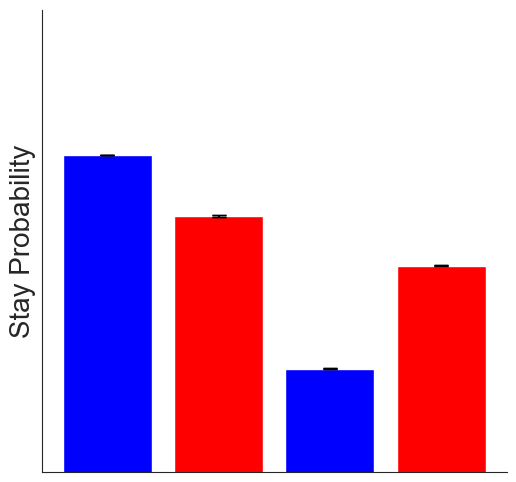

In [ ]:
# Generate 4 bard graphs with error bars
fourBarStore = np.array(fourBarStore)
mean_values = np.mean(fourBarStore, axis=0)
std_values = np.std(fourBarStore, axis=0)
sterror_values = std_values / np.sqrt(fourBarStore.shape[0])
n = fourBarStore.shape[0]
sem_values = std_values / np.sqrt(n)
plt.figure(figsize=(6, 6))


palette = {
    'CR': 'b',  # blue
    'CU': 'b',  # blue
    'RR': 'r',  # orange
    'RU': 'r'   # orange
}

plt.bar(['R1', 'R2', 'R3', 'R4'], mean_values, yerr=sem_values, capsize=5, color=[palette['CR'], palette['RR'], palette['CU'], palette['RU']])
# add error bars
plt.errorbar(['R1', 'R2', 'R3', 'R4'], mean_values, yerr=sem_values, fmt='none', ecolor='black', capsize=5)

plt.ylim(0, 1)
plt.ylabel('Stay Probability', fontsize=20)
# plt.title('Model Stay Probability with Error Bars', fontsize=16)


plt.ylim(0.5, 1)
# plt.title('Model Stay Probability (simulations with Error Bars)', fontsize=16)

# remove ticks x and y axis
plt.xticks([],fontsize=16)
plt.yticks([],fontsize=16)



sns.despine()

# to figure to file svg
# plt.savefig('FiguresGraph_randomWalk_Human2Step/fourBarFigure_human2step_Dec3_10000episodes_1000samples_optModel_newStay.svg')

plt.show()

# Generate graphs from desired parameters

/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_50976/2347035685.py:323: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame({'choices': choice,
/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/Figures Editable/code figures/adtihya_code/helper_functions_SR.py:630: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Condition'] = df_clean.apply(label_condit

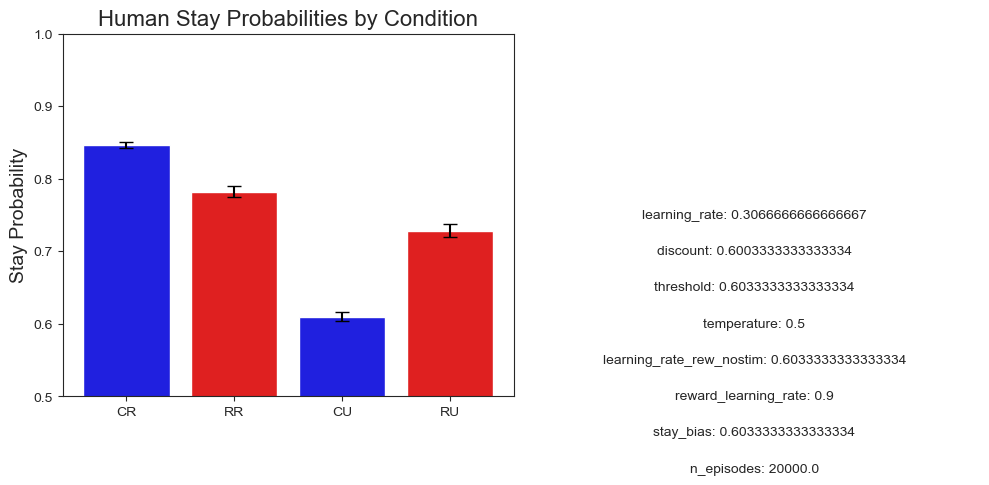

Finished 1/1 combinations


In [ ]:
learning_rates = [ inv_logit(params_max.learning_rate.values[0])]
discounts = [inv_logit(params_max.discount.values[0])]
thresholds = [inv_logit(params_max.threshold.values[0])]
# thresholds = inv_logit(thresholds)
temperatures = [np.log(params_max.temperature.values[0])]
learning_rate_rew_nostims = [inv_logit(params_max.learning_rate_rew_nostim.values[0])]
reward_learning_rates = [inv_logit(params_max.reward_learning_rate.values[0])]
stay_biases = [inv_logit(params_max.stay_bias.values[0])]

n_episodes = 20000

# create a list of all combinations of the parameters
import itertools
import pandas as pd

# create a list of all combinations of the parameters
param_combinations = list(itertools.product(learning_rates, discounts, thresholds, temperatures, learning_rate_rew_nostims, reward_learning_rates, stay_biases))
# above line does not work, 'numpy.float64' object is not iterable
# create a list of all combinations of the parameters

# create a dataframe to store the results
results_df = pd.DataFrame(columns=['learning_rate', 'discount', 'threshold', 'temperature', 'learning_rate_rew_nostim', 'reward_learning_rate', 'stay_bias', 'n_episodes', 'results', 'summary','params'])
# loop over all combinations of the parameters
for i, params in enumerate(param_combinations):
    learning_rate, discount, threshold, temperature, learning_rate_rew_nostim, reward_learning_rate, stay_bias = params
    # run the model
    results, graph_list, values_list, rewards_list, left_prob_list, right_prob_list = doHuman2step(learning_rate, discount, threshold,temperature, learning_rate_rew_nostim, reward_learning_rate, stay_bias,n_episodes)

    params_df = pd.DataFrame({'parameter': [], 'value': []})
    params_df.loc[len(params_df)] = ['learning_rate', logit(learning_rate)]
    params_df.loc[len(params_df)] = ['discount', logit(discount)]
    params_df.loc[len(params_df)] = ['threshold', logit(threshold)]
    params_df.loc[len(params_df)] = ['temperature', np.exp(temperature)]
    params_df.loc[len(params_df)] = ['learning_rate_rew_nostim', logit(learning_rate_rew_nostim)]
    params_df.loc[len(params_df)] = ['reward_learning_rate', logit(reward_learning_rate)]
    params_df.loc[len(params_df)] = ['stay_bias', logit(stay_bias)]
    params_df.loc[len(params_df)] = ['n_episodes', n_episodes]
    


    # get the summary
    summary = plot_from_results_2(results,params_df, filename = f'FiguresGraph_randomWalk_Human2Step/FiguresGraph_Human2Step_randomWalk_GridSearch_model2.svg')
    # add the results to the dataframe
    results_df.loc[i] = [learning_rate, discount, threshold, temperature, learning_rate_rew_nostim, reward_learning_rate, stay_bias, n_episodes, results, summary, params_df]
    # print the progress
    print(f'Finished {i+1}/{len(param_combinations)} combinations')

In [89]:
# save graph_list to pickle


# with open('FiguresGraph_randomWalk_Human2Step/graph_list_simulation_randomWalkProb_for_human2Step_gridSearchOutcome_model2FEB3_stay&forget.pkl', 'wb') as f:
#     pickle.dump(graph_list, f)


In [90]:
# # # load graph_list from file

# with open("FiguresGraph_randomWalk_Human2Step/graph_list_simulation_randomWalkProb_for_human2Step_gridSearchOutcome_model2FEB3_stay&forget.pkl", "rb") as f:
#     graph_list = pickle.load(f)


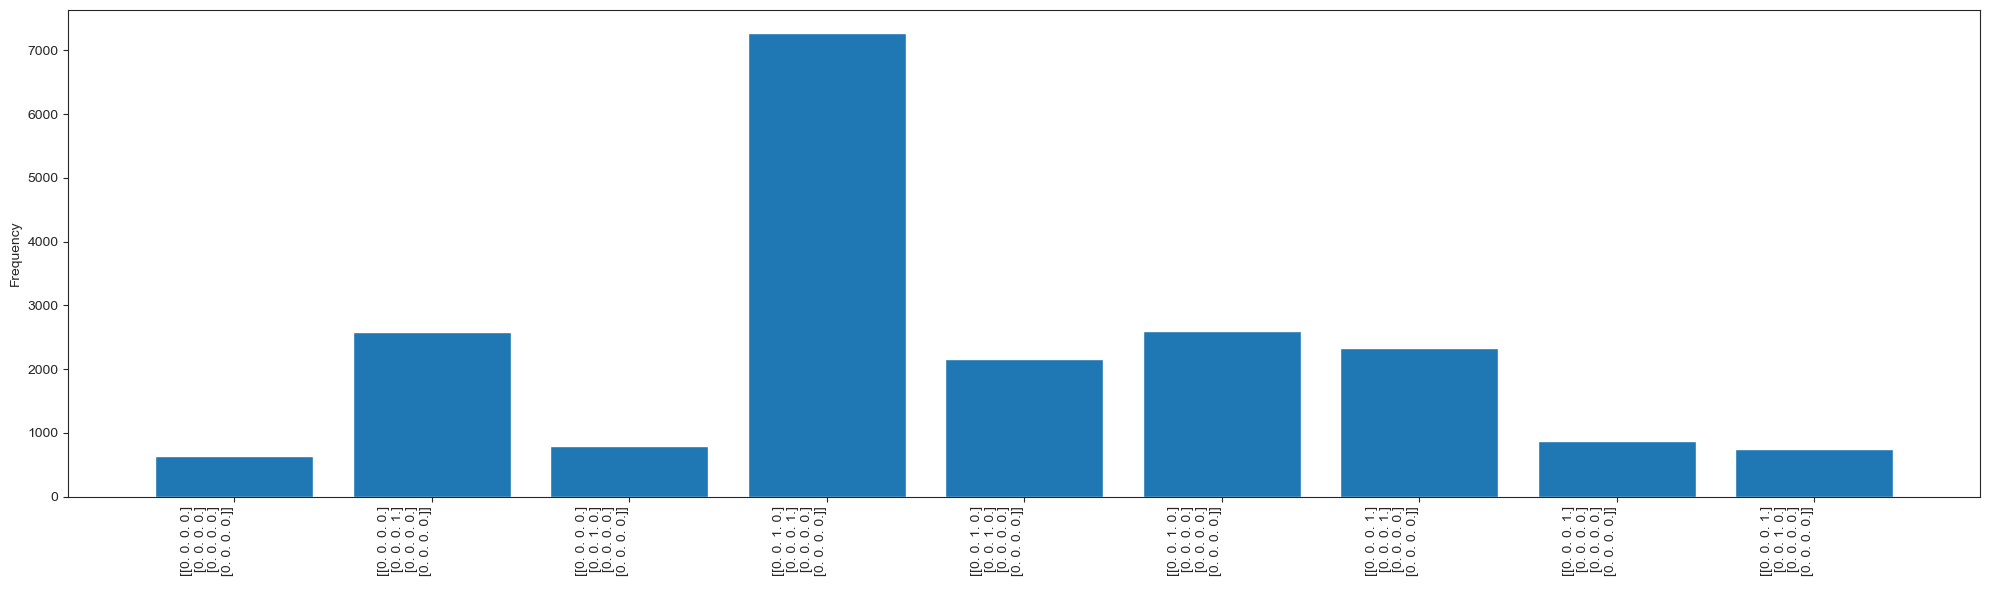

In [93]:
hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_list]


# Count frequencies
counts = Counter(hashable_arrays)

# Prepare labels and values for histogram
labels = [str(np.array(k)) for k in counts.keys()]
values = list(counts.values())

# Plot
plt.figure(figsize=(20, 6))
plt.bar(range(len(values)), values, tick_label=labels)
plt.ylabel("Frequency")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Graphs plots (to check later)
import networkx as nx

states =  ['up','down','left','right']
pos = {'up': (0,0), 'down': (0,1), 'left': (1,0), 'right': (1,1)}


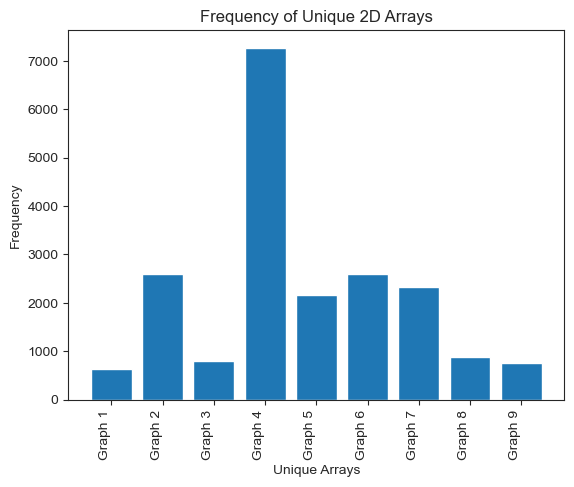

Array #1:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 638
Array #2:
[[0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 2589
Array #3:
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 800
Array #4:
[[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 7270
Array #5:
[[0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 2153
Array #6:
[[0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 2598
Array #7:
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 2334
Array #8:
[[0. 0. 0. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 871
Array #9:
[[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Frequency: 747


In [96]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Example list of 2D arrays
arrays = graph_list

# Convert each 2D array to a tuple-of-tuples for hashing
hashable_arrays = [tuple(map(tuple, arr)) for arr in arrays]

# Count frequencies
counts = Counter(hashable_arrays)

# Make clean labels: Array #1, Array #2, ...
labels = [f"Graph {i+1}" for i in range(len(counts))]
values = list(counts.values())

# Plot histogram
plt.bar(range(len(values)), values, tick_label=labels)
plt.ylabel("Frequency")
plt.xlabel("Unique Arrays")
plt.title("Frequency of Unique 2D Arrays")
plt.xticks(rotation=90, ha='right')

plt.show()

# If you also want to see which ID maps to which array:
for i, arr_tuple in enumerate(counts.keys(), start=1):
    print(f"Array #{i}:\n{np.array(arr_tuple)}\nFrequency: {counts[arr_tuple]}")


In [103]:
states =  ['up','down','left','right']
pos = {'up': (0.5,0.5), 'down': (0.5,1.5), 'left': (1.5,0.5), 'right': (1.5,1.5)}


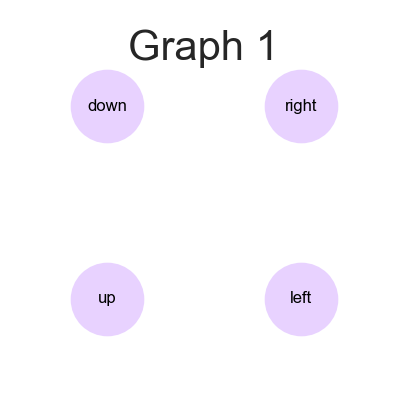

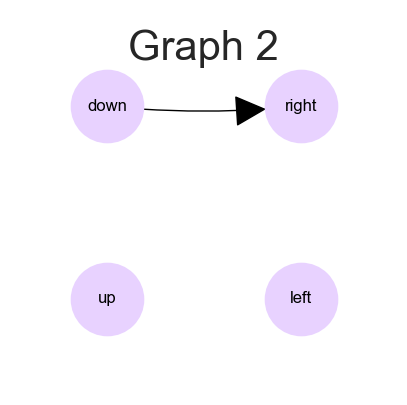

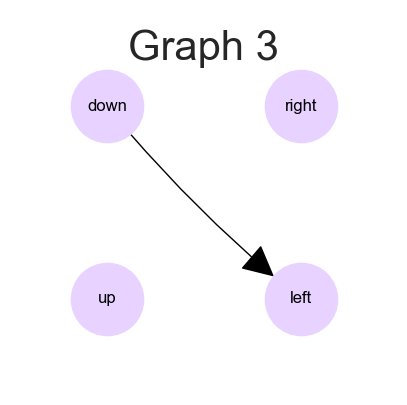

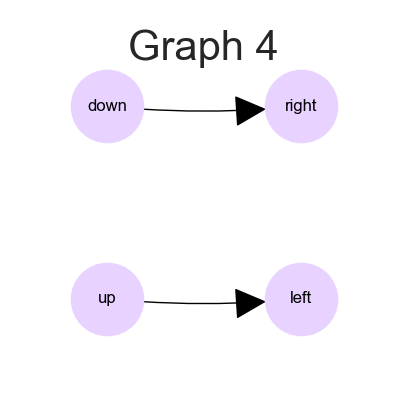

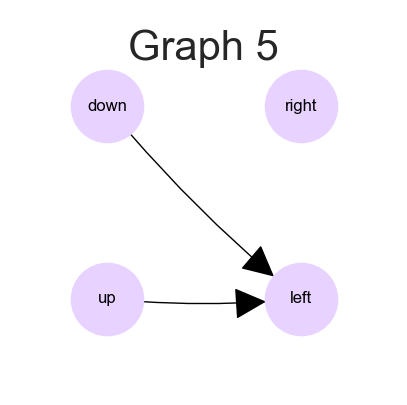

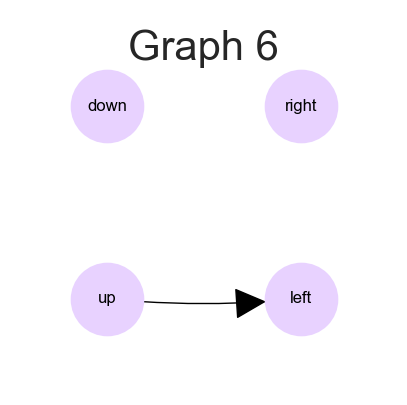

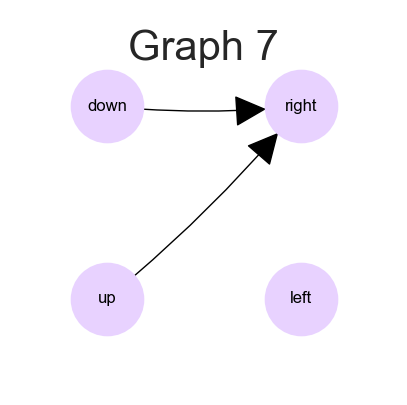

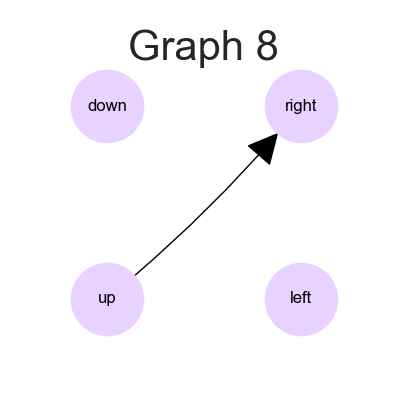

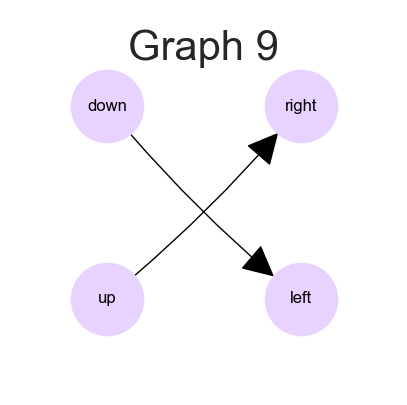

In [104]:
array_unique = list(counts.keys())
for f in range(len(array_unique)):


    mat = array_unique[f]

    fig,ax = plt.subplots(figsize=(5,5))
    node_sizes = 2500

    # plot the graph using nx.digraph
    G = nx.MultiDiGraph()
    G.add_nodes_from(states)
    connectionstyle1 = 'arc3,rad=0.05'
    connectionstyle2 = 'arc3,rad=-0.05'
    edgelist1 = []
    edgelist2 = []
    for i in range(len(states)):
        for j in range(len(states)):
            if mat[i][j] == 1:
                edgelist1.append((states[i],states[j]))

    nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edge_color='black',node_size=node_sizes,  linewidths =3,  node_color= "#e8d2ff",    arrowsize=50)  # default is ~10)
    ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)

    plt.xlim(0, 2)
    plt.ylim(0, 2)

    # save figure to svg
    plt.savefig(f"FiguresGraph_randomWalk_Human2Step/HistogramGraph_Human2Step_{f}_model2_model2_newStay.svg", format='svg', bbox_inches='tight')

    plt.show()




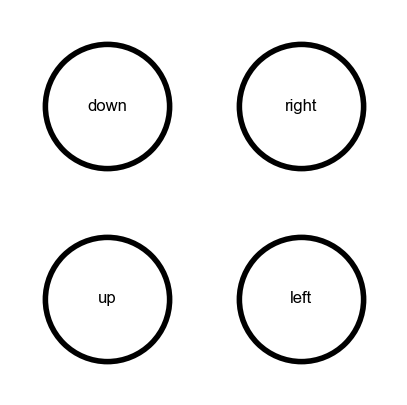

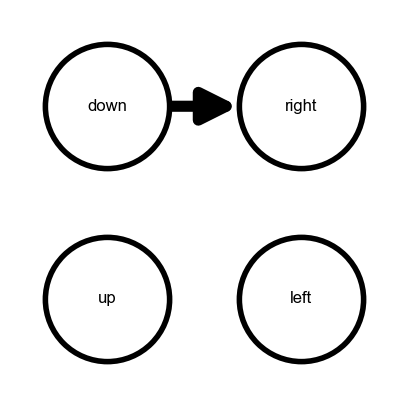

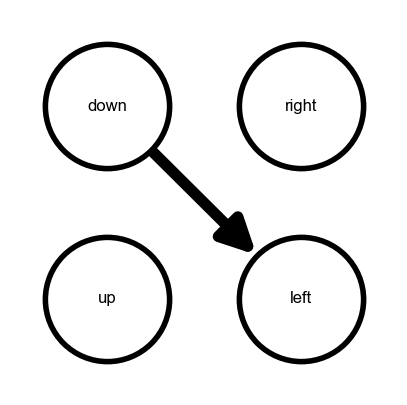

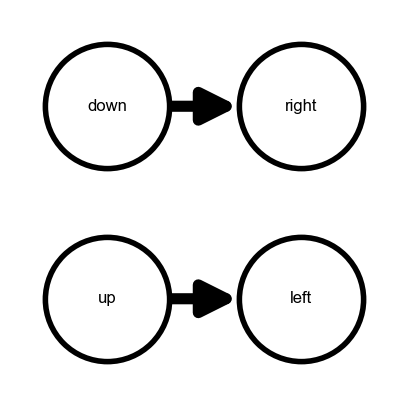

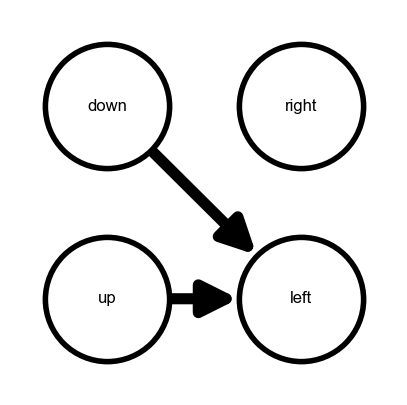

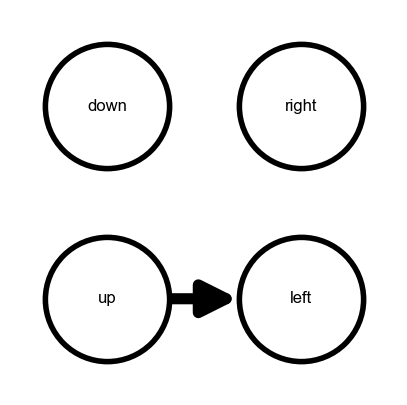

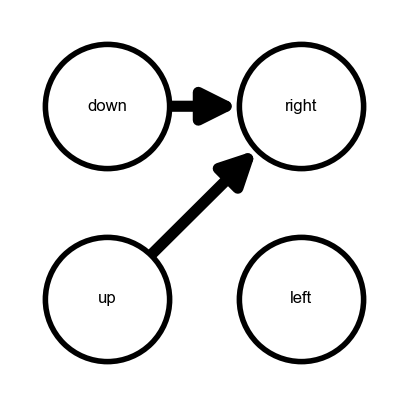

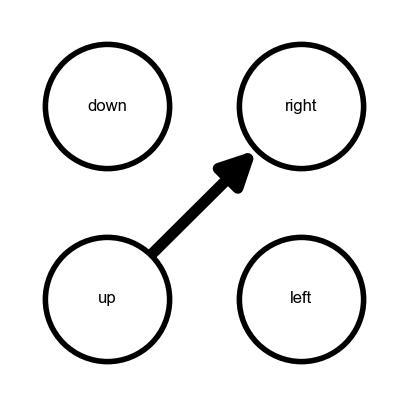

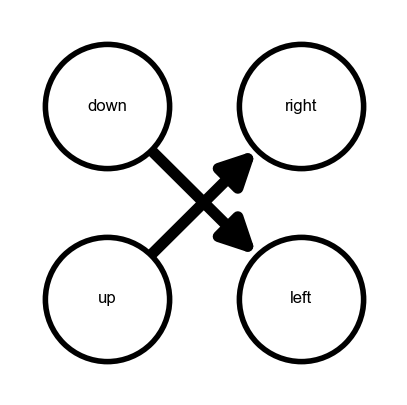

In [106]:
array_unique = list(counts.keys())
for f in range(len(array_unique)):


    mat = array_unique[f]

    fig,ax = plt.subplots(figsize=(5,5))
    node_sizes = 8000

    # plot the graph using nx.digraph
    G = nx.MultiDiGraph()
    G.add_nodes_from(states)
    connectionstyle1 = 'arc3,rad=0.0'
    connectionstyle2 = 'arc3,rad=-0.0'
    edgelist1 = []
    edgelist2 = []
    for i in range(len(states)):
        for j in range(len(states)):
            if mat[i][j] == 1:
                edgelist1.append((states[i],states[j]))

    nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1,edgecolors='black', edge_color='black',node_size=node_sizes,  linewidths =4,  node_shape="o",  node_color= "#FFFFFF",    arrowsize = 50, width=8)  # default is ~10)
    # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)

    plt.xlim(0, 2)
    plt.ylim(0, 2)

    # save figure to svg
    # plt.savefig(f"FiguresGraph_randomWalk_Human2Step/HistogramGraph_Human2Step_{f}_model2_newStay.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"FiguresGraph_randomWalk_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

    plt.show()




In [ ]:
def discrete_cmap(N, base_cmap=None):
    """Create an N-bin discrete colormap from the specified input map"""
    return plt.cm.get_cmap(base_cmap, N)
# colorbar with 11 ticks
cmap = discrete_cmap(11, 'viridis') # Create a discrete colormap with 5 colors from 'viridis'


indices_graph = []
for j in range(len(graph_list)):
    indices = [i for i, arr in enumerate(array_unique) if np.array_equal(graph_list[j], arr)]
    print( i , indices[0])
    indices_graph.append(indices[0])

/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_50976/1917467826.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  return plt.cm.get_cmap(base_cmap, N)


3 0
3 0
3 1
3 2
3 1
3 1
3 1
3 2
3 0
3 2
3 1
3 2
3 1
3 2
3 0
3 2
3 1
3 1
3 1
3 3
3 3
3 3
3 3
3 4
3 4
3 3
3 3
3 3
3 3
3 1
3 2
3 0
3 1
3 1
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 4
3 4
3 5
3 4
3 4
3 5
3 5
3 5
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 6
3 1
3 1
3 2
3 2
3 4
3 5
3 7
3 5
3 7
3 7
3 7
3 5
3 5
3 5
3 7
3 5
3 5
3 5
3 0
3 5
3 5
3 3
3 5
3 3
3 3
3 3
3 4
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 0
3 5
3 7
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 7
3 7
3 0
3 1
3 1
3 1
3 2
3 1
3 2
3 2
3 2
3 1
3 1
3 1
3 1
3 1
3 2
3 1
3 2
3 1
3 1
3 1
3 1
3 1
3 2
3 4
3 4
3 5
3 7
3 7
3 8
3 6
3 6
3 8
3 8
3 4
3 4
3 8
3 6
3 6
3 6
3 1
3 1
3 1
3 1
3 1
3 1
3 1
3 2
3 2
3 1
3 0
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 5
3 3
3 4
3 5
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 4
3 4
3 3
3 3
3 5
3 5
3 5
3 5
3 5
3 5
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 3
3 4
3 3
3 4
3 4
3 4
3 4
3 4
3 4
3 4
3 3
3 3
3 3
3 3
3 3
3 6
3 3
3 6
3 3
3 3
3 3
3 3
3 3
3 3
3 5
3 3
3 3
3 6
3 6
3 1


In [113]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib

In [114]:

cmap = matplotlib.colormaps.get_cmap('turbo')

# Number of colors to extract
N = len(array_unique)

# Sample N colors from the colormap
# np.linspace(0, 1, N) creates N evenly spaced values between 0 and 1
colors_rgba = [cmap(i) for i in np.linspace(0, 1, N)]

# If you want hexadecimal color codes:
hex_colors = [matplotlib.colors.to_hex(color) for color in colors_rgba]


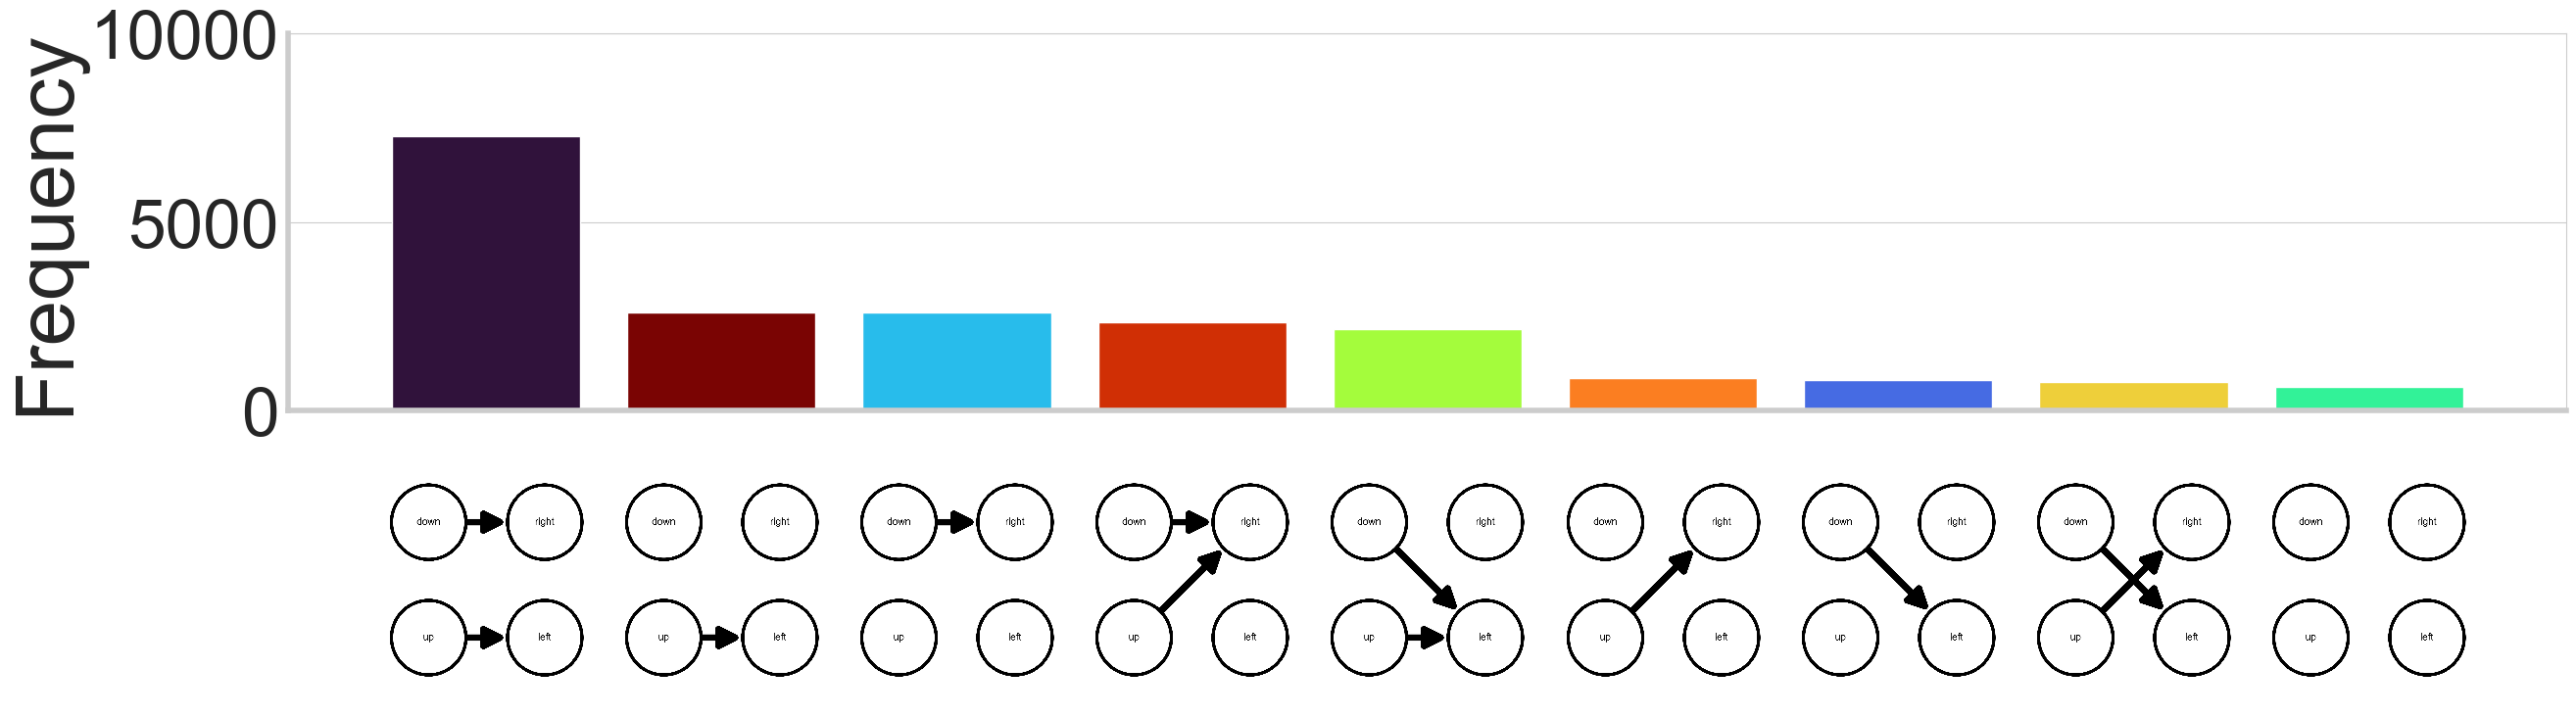

In [127]:

# -------------------
# Step 1: Sort by frequency (ascending)
# -------------------
order = np.argsort(values)[::-1]  # indices sorted low → high
values_sorted = [values[i] for i in order]
labels_sorted = [labels[i] for i in order]

# also reorder images
images = [f"FiguresGraph_randomWalk_Human2Step/HistogramGraph_Human2Step_{i}_colorEdge.png" for i in range(len(y))]
images_sorted = [images[i] for i in order]

# order colors (hex) as well 
hex_colors_sorted = [hex_colors[i] for i in order]

# -------------------
# Step 2: Create a mapping old_index → new_index
# -------------------
mapping = {old: new for new, old in enumerate(order)}
# Apply mapping to indices_graph (shift +1 because y starts at 1, not 0)
indices_graph_mapped = np.array([mapping[idx] + 1 for idx in indices_graph])

# -------------------
# Step 3: Plot
# -------------------
fig, axs = plt.subplots(1, 1, figsize=(30, 5))


# define colors for each bar
colors = sns.color_palette(hex_colors_sorted[::-1], len(y))
# Left subplot: barh
axs.bar(np.arange(1, len(y)+1), values_sorted, color=colors)
# axs.set_yscale('log')



axs.set_ylabel('Frequency', fontsize=60)
axs.tick_params(axis='both', which='major', labelsize=50)

# Remove text y-ticks
# axs.set_yticks(np.arange(1, len(y)+1))
axs.spines['bottom'].set_linewidth(4)
axs.spines['left'].set_linewidth(4)
# remove ticks on x axis
axs.set_xticks([])

# Add images as "labels"
for (yi, img_path) in zip(np.arange(1, len(y)+1), images_sorted):
    img = mpimg.imread(img_path)
    imagebox = OffsetImage(img, zoom=0.11)


    ab = AnnotationBbox(imagebox, (yi, 1),
                        xybox=(0,-125),
                        xycoords='data',
                        boxcoords="offset points",
                        frameon=False)
    axs.add_artist(ab)

axs.set_yticks([0,5000,10000])

# save figure svg
plt.savefig("FiguresGraph_randomWalk_Human2Step/SGM2025_Human2Step_histogramGraphs_simulations_noLog_colorEdge_modelfromGrid_newStay.pdf", format='pdf', bbox_inches='tight')